In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

import pyperclip

# Metadata observations

## Load data

In [2]:
df = pd.read_csv("outputs/2.0-discovery_results.csv")
df

,snapshot_id,snapshot_type,source,model,metadata_field,observed_value,description,source_level,discovery_value,reasoning
0,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,figure_title,Figure 2: Share of food expenditure in total e...,The title or caption identifying the figure an...,snapshot,high,The figure title provides the most direct sear...
1,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,indicator_name,Share of food expenditure in total expenditure...,The main measure or indicator represented in t...,snapshot,high,Indicator-level metadata enables retrieval of ...
2,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,subject_domain,Food expenditure; food security,The thematic domain or topical area represente...,both,high,The figure title and document metadata both co...
3,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,geographic_scope,"Jordan, inferred from parent document title an...","The country, region, or geographic area to whi...",document,high,Geographic context is essential for discovery ...
4,027_Jordan-Emergency-Food-Security-Project_fig...,figure,refugee,gpt-5.5,time_period,Not identifiable from this snapshot,"The date, year, or period covered by the data ...",snapshot,high,A data time period would be highly useful for ...
...,...,...,...,...,...,...,...,...,...,...
3036,document_10395051_table_002.png,table,prwp,gpt-5.5,significance_notation,"*, ** and *** denote significance at the 10 pe...",Notation used to indicate statistical signific...,snapshot,medium,Significance notation is needed to interpret c...
3037,document_10395051_table_002.png,table,prwp,gpt-5.5,robustness_adjustment,Heteroskedasticity-robust t(z)-statistics are ...,Adjustments or corrections applied to reported...,snapshot,medium,Inference adjustments improve reuse by indicat...
3038,document_10395051_table_002.png,table,prwp,gpt-5.5,endogenous_variable,Each of four informality measures,Variables treated as endogenous in instrumenta...,snapshot,medium,Endogeneity treatment is important for underst...
3039,document_10395051_table_002.png,table,prwp,gpt-5.5,instrumental_variables,Law and order; Business regulatory freedom; Av...,Instruments used in instrumental-variable regr...,snapshot,high,Instrumental variables are key metadata for di...


In [3]:
print("Metadata observations CSV:")
for x in df.columns:
    print("- ", x)

Metadata observations CSV:
-  snapshot_id
-  snapshot_type
-  source
-  model
-  metadata_field
-  observed_value
-  description
-  source_level
-  discovery_value
-  reasoning


## Productivity

In [4]:
obs_count = df.groupby("snapshot_id").agg(obs_count=("snapshot_id", "count"))

print("Number of snapshots:", df["snapshot_id"].nunique())
print("Number of metadata observations:", len(df))
print("Mean observations per snapshot:", obs_count.mean().values[0])
print("Median:", obs_count.median().values[0])
print("Std dev:", obs_count.std().values[0])
print("Min:", obs_count.min().values[0])
print("Max:", obs_count.max().values[0])

Number of snapshots: 210
Number of metadata observations: 3041
Mean observations per snapshot: 14.480952380952381
Median: 15.0
Std dev: 0.8923486818337216
Min: 10
Max: 16


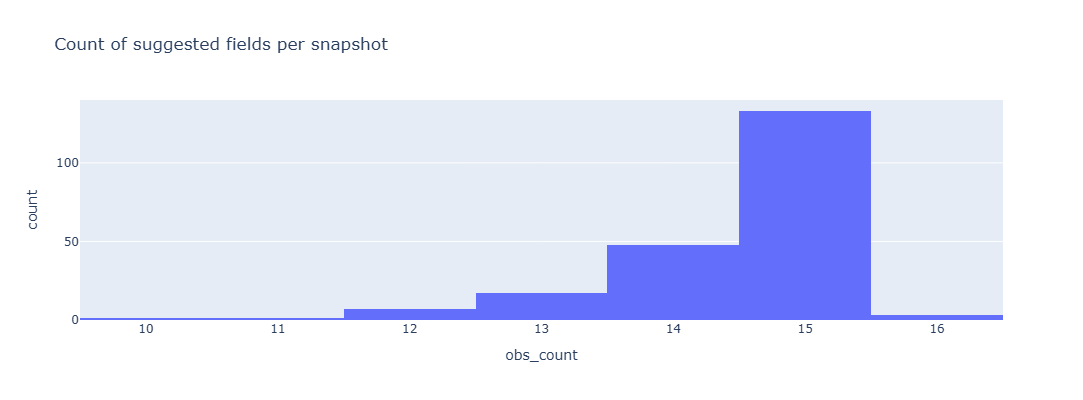

In [5]:
fig = px.histogram(
    obs_count,
    x="obs_count",
    width=600,
    height=400,
    title="Count of suggested fields per snapshot",
)
fig.show()

In [6]:
print(obs_count["obs_count"].value_counts().sort_index().to_markdown())

|   obs_count |   count |
|------------:|--------:|
|          10 |       1 |
|          11 |       1 |
|          12 |       7 |
|          13 |      17 |
|          14 |      48 |
|          15 |     133 |
|          16 |       3 |


Note: Take into account that the prompt specifically says "Limit the output to the 10–15 most useful reusable metadata fields. Do not attempt to exhaustively enumerate every possible field."

## Discovery diversity

In [7]:
field_count = (
    df.groupby("metadata_field")
    .agg(count=("snapshot_id", "nunique"))
    .sort_values("count", ascending=False)
)

print("Number of unique suggested metadata fields:", df["metadata_field"].nunique())
print("Mean snapshot count per suggested metadata field:", field_count.mean().values[0])
print("Median:", field_count.median().values[0])
print("Std dev:", field_count.std().values[0])
print("Min:", field_count.min().values[0])
print("Max:", field_count.max().values[0])

Number of unique suggested metadata fields: 833
Mean snapshot count per suggested metadata field: 3.650660264105642
Median: 1.0
Std dev: 14.485625423656682
Min: 1
Max: 192


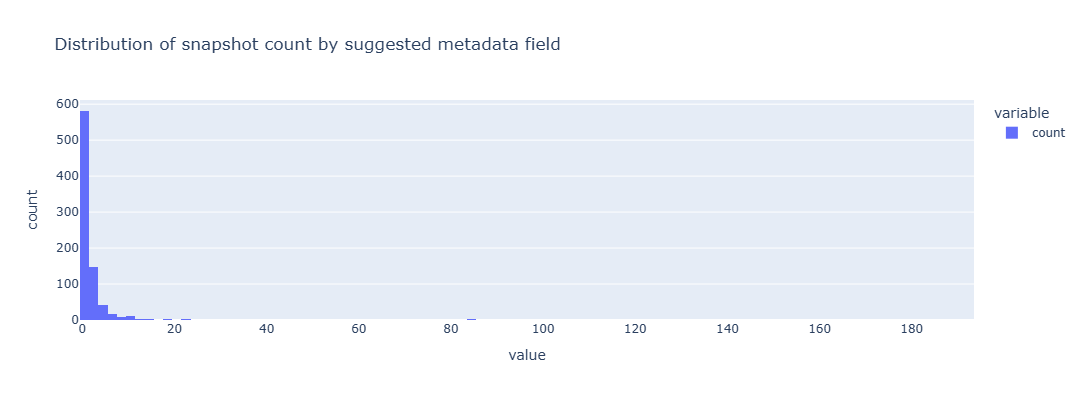

In [8]:
fig = px.histogram(
    field_count,
    # x="count",
    width=800,
    height=400,
    title="Distribution of snapshot count by suggested metadata field",
    nbins=100
)
fig.show()

In [9]:
bins = [0, 1, 2, 3, 4, 5, 10, 15, 20, 50, 100, 150, 200, 1000]
field_count['range'] = pd.cut(field_count['count'], bins=bins)
grouped_freq = field_count['range'].value_counts().sort_index()
print(grouped_freq.to_markdown())

| range       |   count |
|:------------|--------:|
| (0, 1]      |     581 |
| (1, 2]      |     107 |
| (2, 3]      |      39 |
| (3, 4]      |      22 |
| (4, 5]      |      19 |
| (5, 10]     |      32 |
| (10, 15]    |      12 |
| (15, 20]    |       4 |
| (20, 50]    |       5 |
| (50, 100]   |       7 |
| (100, 150]  |       2 |
| (150, 200]  |       3 |
| (200, 1000] |       0 |


Singletons: 581

Top-k coverage
Top 10 fields: 1220 (40.12%)
Top 20 fields: 1545 (50.81%)
Top 50 fields: 1855 (61.00%)
Top 100 fields: 2105 (69.22%)


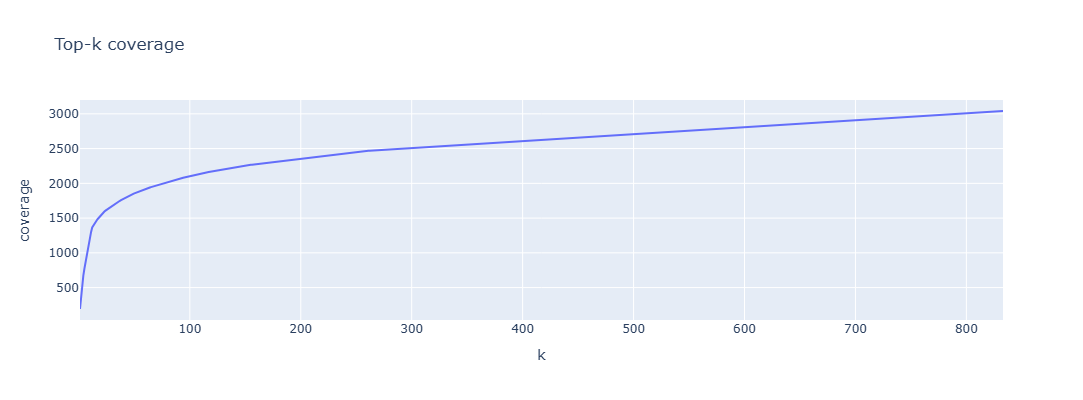

In [10]:
print("Singletons:", len(field_count[field_count["count"] == 1]))

print("\nTop-k coverage")
for x in [10, 20, 50, 100]:
    val = field_count.sort_values("count", ascending=False).head(x)["count"].sum()
    pct = 100 * val / field_count["count"].sum()
    print(f"Top {x} fields: {val} ({pct:.2f}%)")

field_count["k"] = range(1, len(field_count) + 1)
field_count["coverage"] = field_count["count"].cumsum()

px.line(field_count, x="k", y="coverage", width=800, height=400, title="Top-k coverage")

Vocabulary concentration
Top 5 fields cover 25.49% of observations
Top 19 fields cover 50.18% of observations
Top 163 fields cover 75.04% of observations
Top 529 fields cover 90.00% of observations


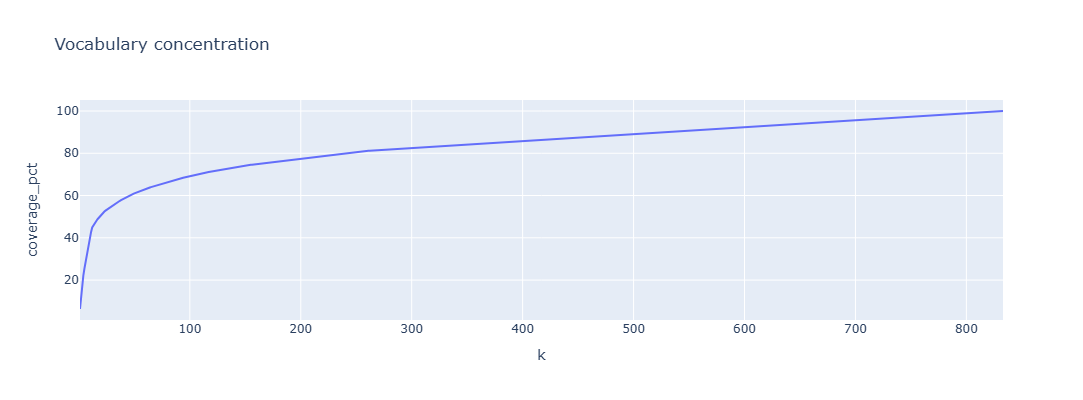

In [11]:
field_count["coverage_pct"] = 100.0 * field_count["coverage"] / 3041

print("Vocabulary concentration")
for x in [25, 50, 75, 90]:
    k = field_count[field_count["coverage_pct"] > x]["k"].min()
    cov = field_count[field_count["coverage_pct"] > x]["coverage_pct"].min()
    print(f"Top {k} fields cover {cov:.2f}% of observations")

px.line(
    field_count,
    x="k",
    y="coverage_pct",
    width=800,
    height=400,
    title="Vocabulary concentration",
)

## Corpus comparison

In [12]:
for s in ["unhcr", "prwp", "refugee"]:
    print(s)
    print("Number of observations:", df[df["source"] == s]["metadata_field"].count())
    print("Mean observation count per snapshot:", df[df["source"] == s].groupby("snapshot_id").agg(count=("snapshot_id", "count")).mean().values[0])
    print("Number of unique suggested metadata fields:", df[df["source"] == s]["metadata_field"].nunique())

    field_count_ = df[df["source"] == s].groupby("metadata_field").agg(count=("snapshot_id", "nunique"))
    print("Mean snapshot count per suggested metadata field:", field_count_.mean().values[0])
    print("Median snapshot count per suggested metadata field:", field_count_.median().values[0])
    print("Std dev snapshot count per suggested metadata field:", field_count_.std().values[0])
    print("Min snapshot count per suggested metadata field:", field_count_.min().values[0])
    print("Max snapshot count per suggested metadata field:", field_count_.max().values[0])

    print("---")

unhcr
Number of observations: 972
Mean observation count per snapshot: 13.885714285714286
Number of unique suggested metadata fields: 323
Mean snapshot count per suggested metadata field: 3.0092879256965945
Median snapshot count per suggested metadata field: 1.0
Std dev snapshot count per suggested metadata field: 8.176046694673857
Min snapshot count per suggested metadata field: 1
Max snapshot count per suggested metadata field: 68
---
prwp
Number of observations: 1028
Mean observation count per snapshot: 14.685714285714285
Number of unique suggested metadata fields: 344
Mean snapshot count per suggested metadata field: 2.988372093023256
Median snapshot count per suggested metadata field: 1.0
Std dev snapshot count per suggested metadata field: 6.945844970683549
Min snapshot count per suggested metadata field: 1
Max snapshot count per suggested metadata field: 67
---
refugee
Number of observations: 1041
Mean observation count per snapshot: 14.871428571428572
Number of unique suggested

In [13]:
# Vocabulary overlap
voc_unhcr = set(df[df["source"] == "unhcr"]["metadata_field"].unique())
voc_prwp = set(df[df["source"] == "prwp"]["metadata_field"].unique())
voc_refugee = set(df[df["source"] == "refugee"]["metadata_field"].unique())

print("Pairwise jaccard")
print("UNHCR and PRWP:", len(voc_unhcr & voc_prwp) / len(voc_unhcr | voc_prwp))
print("UNHCR and Refugee:", len(voc_unhcr & voc_refugee) / len(voc_unhcr | voc_refugee))
print("PRWP and Refugee:", len(voc_refugee & voc_prwp) / len(voc_refugee | voc_prwp))

print("\nTriple intersection:", len(voc_unhcr & voc_prwp & voc_refugee))

print("\nOnly in UNHCR:", len(voc_unhcr - voc_prwp - voc_refugee))
print("Only in PRWP:", len(voc_prwp - voc_unhcr - voc_refugee))
print("Only in Refugee:", len(voc_refugee - voc_unhcr - voc_prwp))

Pairwise jaccard
UNHCR and PRWP: 0.11538461538461539
UNHCR and Refugee: 0.1381692573402418
PRWP and Refugee: 0.09854604200323101

Triple intersection: 40

Only in UNHCR: 214
Only in PRWP: 254
Only in Refugee: 235


## Figure vs Table

In [14]:
for s in ["figure", "table"]:
    print(s)
    print("Number of observations:", df[df["snapshot_type"] == s]["metadata_field"].count())
    print("Mean observation count per snapshot:", df[df["snapshot_type"] == s].groupby("snapshot_id").agg(count=("snapshot_id", "count")).mean().values[0])
    print("Number of unique suggested metadata fields:", df[df["snapshot_type"] == s]["metadata_field"].nunique())

    field_count_ = df[df["snapshot_type"] == s].groupby("metadata_field").agg(count=("snapshot_id", "nunique"))
    print("Mean snapshot count per suggested metadata field:", field_count_.mean().values[0])
    print("Median snapshot count per suggested metadata field:", field_count_.median().values[0])
    print("Std dev snapshot count per suggested metadata field:", field_count_.std().values[0])
    print("Min snapshot count per suggested metadata field:", field_count_.min().values[0])
    print("Max snapshot count per suggested metadata field:", field_count_.max().values[0])

    print("---")

figure
Number of observations: 1509
Mean observation count per snapshot: 14.371428571428572
Number of unique suggested metadata fields: 432
Mean snapshot count per suggested metadata field: 3.4930555555555554
Median snapshot count per suggested metadata field: 1.0
Std dev snapshot count per suggested metadata field: 11.39177657227109
Min snapshot count per suggested metadata field: 1
Max snapshot count per suggested metadata field: 98
---
table
Number of observations: 1532
Mean observation count per snapshot: 14.59047619047619
Number of unique suggested metadata fields: 504
Mean snapshot count per suggested metadata field: 3.0396825396825395
Median snapshot count per suggested metadata field: 1.0
Std dev snapshot count per suggested metadata field: 9.662207983669909
Min snapshot count per suggested metadata field: 1
Max snapshot count per suggested metadata field: 96
---


In [15]:
# Vocabulary overlap
voc_figure = set(df[df["snapshot_type"] == "figure"]["metadata_field"].unique())
voc_table = set(df[df["snapshot_type"] == "table"]["metadata_field"].unique())

print("Pairwise jaccard:", len(voc_figure & voc_table) / len(voc_figure | voc_table))
print("Intersection:", len(voc_figure & voc_table))

print("\nOnly in figure:", len(voc_figure - voc_table))
print("Only in table:", len(voc_table - voc_figure))

Pairwise jaccard: 0.12364945978391356
Intersection: 103

Only in figure: 329
Only in table: 401


In [16]:
print("Top 10 figure fields:")
print(df[df["snapshot_type"] == "figure"]["metadata_field"].value_counts().head(10).to_markdown())

print("\nTop 10 table fields:")
print(df[df["snapshot_type"] == "table"]["metadata_field"].value_counts().head(10).to_markdown())

Top 10 figure fields:
| metadata_field     |   count |
|:-------------------|--------:|
| unit_of_measure    |      98 |
| visualization_type |      96 |
| geographic_scope   |      96 |
| indicator_name     |      89 |
| time_period        |      86 |
| figure_title       |      81 |
| source_citation    |      57 |
| category_labels    |      43 |
| population_group   |      41 |
| category_values    |      23 |

Top 10 table fields:
| metadata_field   |   count |
|:-----------------|--------:|
| geographic_scope |      96 |
| table_title      |      89 |
| row_dimension    |      86 |
| unit_of_measure  |      82 |
| column_dimension |      74 |
| indicator_name   |      63 |
| time_period      |      63 |
| population_group |      43 |
| project_name     |      26 |
| source_citation  |      24 |


## Vocabulary accumulation curve

In [17]:
acc_fields = set()
acc_snapshot = set()
snapshots = df["snapshot_id"].unique().tolist()
# np.random.shuffle(snapshots)

acc_curve = {}  # n_unique_snapshots: n_unique_fields
for x in snapshots:
    acc_snapshot.add(x)
    acc_fields.update(df[df["snapshot_id"] == x]["metadata_field"].unique().tolist())

    acc_curve[len(acc_snapshot)] = len(acc_fields)

acc_curve_df = (
    pd.Series(acc_curve)
    .rename("unique_metadata_field_count")
    .to_frame()
    .reset_index(names="unique_snapshot_count")
)

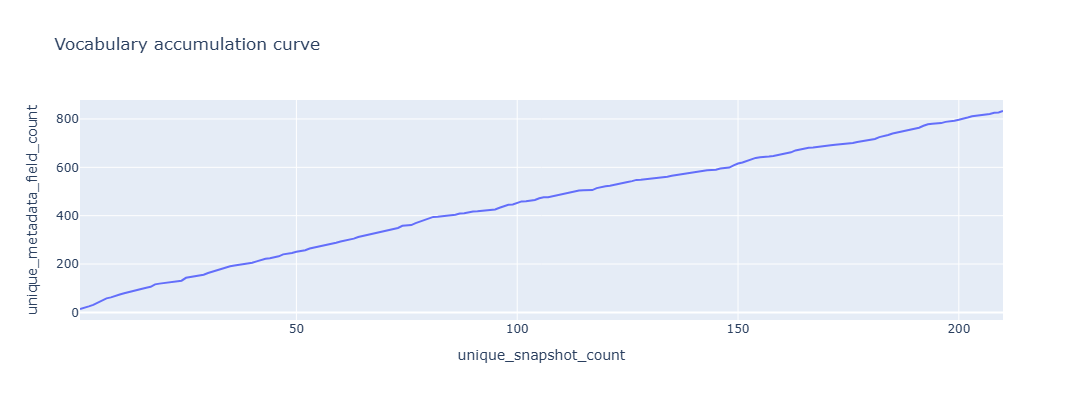

In [18]:
px.line(
    acc_curve_df,
    x="unique_snapshot_count",
    y="unique_metadata_field_count",
    height=400,
    width=800,
    title="Vocabulary accumulation curve"
)

In [19]:
print(acc_curve_df.iloc[::20].to_markdown(index=False))

|   unique_snapshot_count |   unique_metadata_field_count |
|------------------------:|------------------------------:|
|                       1 |                            14 |
|                      21 |                           123 |
|                      41 |                           211 |
|                      61 |                           296 |
|                      81 |                           395 |
|                     101 |                           459 |
|                     121 |                           524 |
|                     141 |                           581 |
|                     161 |                           656 |
|                     181 |                           717 |
|                     201 |                           800 |


In [20]:
print(acc_curve_df.tail(11).iloc[::2].to_markdown(index=False))

|   unique_snapshot_count |   unique_metadata_field_count |
|------------------------:|------------------------------:|
|                     200 |                           797 |
|                     202 |                           806 |
|                     204 |                           813 |
|                     206 |                           816 |
|                     208 |                           826 |
|                     210 |                           833 |


In [21]:
acc_curve_df["new_discovered_fields"] = acc_curve_df["unique_metadata_field_count"].diff()

print("Average discovery rate per snapshot:", acc_curve_df["new_discovered_fields"].mean())

Average discovery rate per snapshot: 3.9186602870813396


Even after shuffling the dataset 5 times, average discovery rate is around 3.92.

In [22]:
print(acc_curve_df.head(10).to_markdown(index=False))

|   unique_snapshot_count |   unique_metadata_field_count |   new_discovered_fields |
|------------------------:|------------------------------:|------------------------:|
|                       1 |                            14 |                     nan |
|                       2 |                            21 |                       7 |
|                       3 |                            25 |                       4 |
|                       4 |                            31 |                       6 |
|                       5 |                            41 |                      10 |
|                       6 |                            51 |                      10 |
|                       7 |                            58 |                       7 |
|                       8 |                            62 |                       4 |
|                       9 |                            69 |                       7 |
|                      10 |                           

In [23]:
acc_curve_df["rolling_mean_5"] = acc_curve_df["new_discovered_fields"].rolling(window=5).mean()
acc_curve_df.head(10)

,unique_snapshot_count,unique_metadata_field_count,new_discovered_fields,rolling_mean_5
0,1,14,NaN,NaN
1,2,21,7.0,NaN
2,3,25,4.0,NaN
3,4,31,6.0,NaN
4,5,41,10.0,NaN
5,6,51,10.0,7.4
6,7,58,7.0,7.4
7,8,62,4.0,7.4
8,9,69,7.0,7.6
9,10,74,5.0,6.6


In [24]:
acc_curve_df.tail(10)

,unique_snapshot_count,unique_metadata_field_count,new_discovered_fields,rolling_mean_5
200,201,800,3.0,3.4
201,202,806,6.0,3.6
202,203,811,5.0,4.4
203,204,813,2.0,4.0
204,205,814,1.0,3.4
205,206,816,2.0,3.2
206,207,821,5.0,3.0
207,208,826,5.0,3.0
208,209,827,1.0,2.8
209,210,833,6.0,3.8


In [25]:
acc_curve_df["rolling_mean_5"].describe()

count    205.000000
mean       3.893659
std        1.223868
min        1.400000
25%        3.000000
50%        4.000000
75%        4.600000
max        7.600000
Name: rolling_mean_5, dtype: float64

## First appearance analysis

In [26]:
appearance_dict = {}  # metadata_field: nth_observation
appearance_container = set()

i = 0
snapshot_id = None
for _, row in df.iterrows():
    if snapshot_id != row["snapshot_id"]:
        i += 1
        snapshot_id = row["snapshot_id"]

    f = row["metadata_field"]
    if f in appearance_container:
        continue

    appearance_dict[f] = i
    appearance_container.add(f)

appearance_df = (
    pd.Series(appearance_dict)
    .rename("nth_snapshot")
    .to_frame()
    .reset_index(names="metadata_field")
)
appearance_df

,metadata_field,nth_snapshot
0,figure_title,1
1,indicator_name,1
2,subject_domain,1
3,geographic_scope,1
4,time_period,1
...,...,...
828,indicator_units,210
829,statistical_measures_reported,210
830,robustness_adjustment,210
831,endogenous_variable,210


In [27]:
appearance_df_hist = appearance_df.groupby("nth_snapshot").agg(count=("metadata_field", "count"))
appearance_df_hist

,count
nth_snapshot,
1,14
2,7
3,4
4,6
5,10
...,...
206,2
207,5
208,5


In [28]:
print(appearance_df_hist.head(10).to_markdown())

|   nth_snapshot |   count |
|---------------:|--------:|
|              1 |      14 |
|              2 |       7 |
|              3 |       4 |
|              4 |       6 |
|              5 |      10 |
|              6 |      10 |
|              7 |       7 |
|              8 |       4 |
|              9 |       7 |
|             10 |       5 |


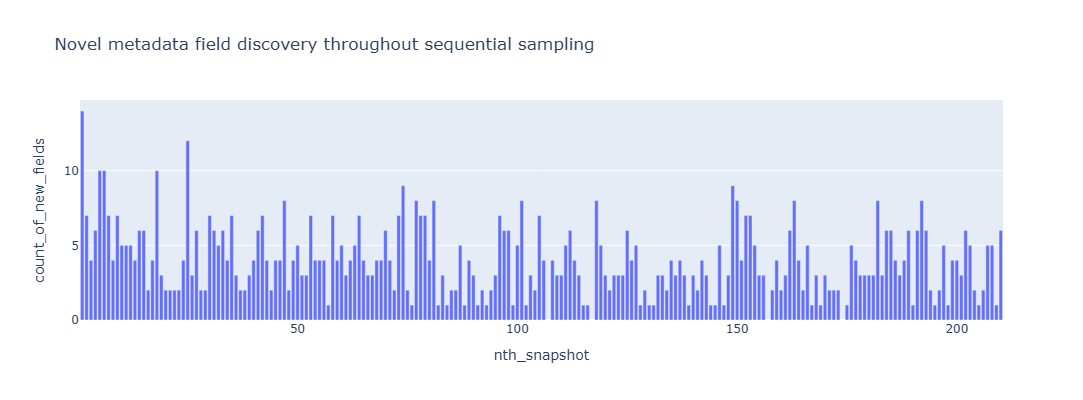

In [29]:
# TODO: Overlay 5-point rolling average
px.bar(
    appearance_df_hist.reset_index().rename(columns={"count": "count_of_new_fields"}),
    x="nth_snapshot",
    y="count_of_new_fields",
    title="Novel metadata field discovery throughout sequential sampling",
    width=1000,
    height=400,
)

## Corpus breadth

In [30]:
breadth_dict = {}  # metadata_field: n_corpus
for f in df["metadata_field"].unique().tolist():
    b = (f in voc_unhcr) + (f in voc_prwp) + (f in voc_refugee)
    breadth_dict[f] = b

In [31]:
breadth_df = (
    pd.Series(breadth_dict)
    .rename("corpus_count")
    .to_frame()
    .reset_index(names="metadata_field")
)
print(breadth_df.groupby("corpus_count").agg(count=("corpus_count", "count")).to_markdown())

|   corpus_count |   count |
|---------------:|--------:|
|              1 |     703 |
|              2 |      90 |
|              3 |      40 |


In [32]:
common_fields = breadth_df[breadth_df["corpus_count"] == 3]["metadata_field"].tolist()
print(df[df["metadata_field"].isin(common_fields)]["metadata_field"].value_counts().head(20).to_markdown())

| metadata_field       |   count |
|:---------------------|--------:|
| geographic_scope     |     192 |
| unit_of_measure      |     180 |
| indicator_name       |     152 |
| time_period          |     149 |
| row_dimension        |     102 |
| visualization_type   |      99 |
| table_title          |      90 |
| column_dimension     |      88 |
| population_group     |      84 |
| figure_title         |      84 |
| source_citation      |      81 |
| category_labels      |      64 |
| category_values      |      27 |
| category_dimension   |      22 |
| currency             |      22 |
| series_labels        |      22 |
| subject_domain       |      19 |
| sector               |      19 |
| x_axis_dimension     |      13 |
| temporal_granularity |      12 |


In [33]:
single_fields = breadth_df[breadth_df["corpus_count"] == 1]["metadata_field"].tolist()
single_fields_count = (
    df[df["metadata_field"].isin(single_fields)]
    .groupby("metadata_field")
    .agg(count=("metadata_field", "count"))
)

single_fields_count[single_fields_count["count"] == 1].head(20)

,count
metadata_field,
abbreviation_terms,1
abbreviations,1
access_point,1
actual_value,1
administrative_areas_highlighted,1
administrative_boundary_type,1
administrative_boundary_types,1
administrative_location,1
affected_population_group,1
